In [1]:
# ============================
# STEP 1
# Environment Setup
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Create a table of library versions

versions = pd.DataFrame({
    "Library": ["NumPy", "Pandas", "Matplotlib", "Seaborn"],
    "Version": [
        np.__version__,
        pd.__version__,
        plt.matplotlib.__version__,
        sns.__version__
    ]
})

print("Library Versions")
print("="*40)
print(versions)

Library Versions
      Library Version
0       NumPy   2.0.2
1      Pandas   2.2.2
2  Matplotlib  3.10.0
3     Seaborn  0.13.2


In [3]:
# ============================
# STEP 2
# Load and Preview Dataset
# ============================

# Load the dataset

df= pd.read_csv("/content/StudentsPerformance.csv")

# Display first 10 rows
print("=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)
print(df.head(10))

# Display last 5 rows
print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
print(df.tail(5))

# Display random 8 rows
print("\n" + "=" * 60)
print("RANDOM SAMPLE OF 8 ROWS")
print("=" * 60)
print(df.sample(8, random_state=42))

FIRST 10 ROWS
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2    

In [4]:
# ============================
# STEP 3
# Dataset Structure Analysis
# ============================

# Display shape of dataset
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(df.shape)

# Display dataset information
print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

# Display data types
print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
print(df.dtypes)

# Display column names
print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())

# Count numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("\n" + "=" * 60)
print("NUMBER OF NUMERICAL COLUMNS")
print("=" * 60)
print(len(numerical_columns))

print("\n" + "=" * 60)
print("NUMBER OF CATEGORICAL COLUMNS")
print("=" * 60)
print(len(categorical_columns))

DATASET SHAPE
(1000, 8)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

COLUMN DATA TYPES
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score          

MISSING VALUES
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

MISSING VALUE PERCENTAGE
gender                         0.0
race/ethnicity                 0.0
parental level of education    0.0
lunch                          0.0
test preparation course        0.0
math score                     0.0
reading score                  0.0
writing score                  0.0
dtype: float64

DUPLICATE ROWS
Total Duplicate Rows: 0


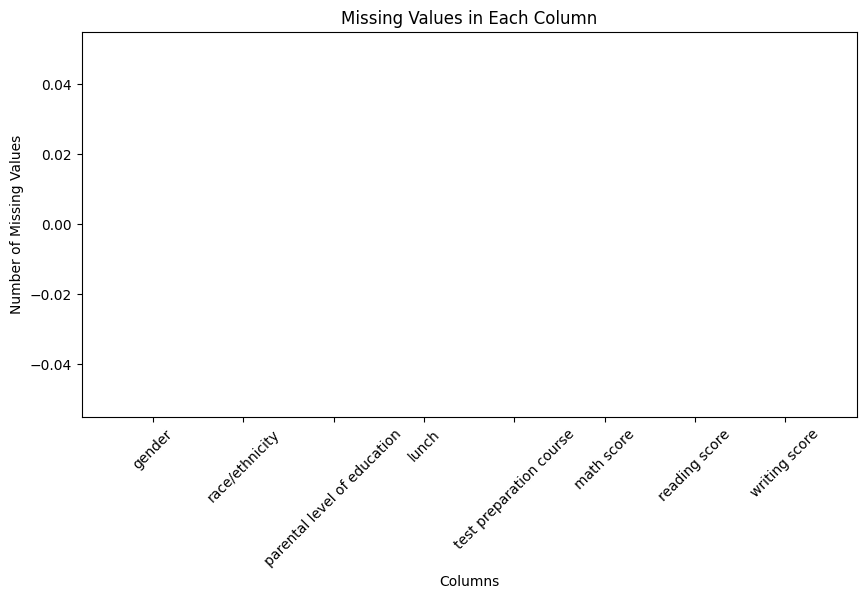

In [5]:
# ============================
# STEP 4
# Missing Value & Duplicate Analysis
# ============================

# Count missing values
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()
print(missing_values)

# Percentage of missing values
print("\n" + "=" * 60)
print("MISSING VALUE PERCENTAGE")
print("=" * 60)

missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

# Check duplicate rows
print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

duplicates = df.duplicated().sum()
print("Total Duplicate Rows:", duplicates)

# Bar chart of missing values
plt.figure(figsize=(10,5))
plt.bar(missing_values.index, missing_values.values)

plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.show()

In [6]:
# ============================
# STEP 5
# Descriptive Statistics
# ============================

# Display descriptive statistics
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

print(df.describe())

# List of score columns
score_columns = ['math score', 'reading score', 'writing score']

# Create summary DataFrame
summary_df = pd.DataFrame(index=score_columns)

summary_df['Mean'] = df[score_columns].mean()
summary_df['Median'] = df[score_columns].median()
summary_df['Mode'] = df[score_columns].mode().iloc[0]
summary_df['Standard Deviation'] = df[score_columns].std()
summary_df['Variance'] = df[score_columns].var()
summary_df['Minimum'] = df[score_columns].min()
summary_df['Maximum'] = df[score_columns].max()
summary_df['Range'] = summary_df['Maximum'] - summary_df['Minimum']

# Round values to 2 decimal places
summary_df = summary_df.round(2)

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print(summary_df)

DESCRIPTIVE STATISTICS
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000

SUMMARY STATISTICS
                Mean  Median  Mode  Standard Deviation  Variance  Minimum  \
math score     66.09    66.0    65               15.16    229.92        0   
reading score  69.17    70.0    72               14.60    213.17       17   
writing score  68.05    69.0    74               15.20    230.91       10   

               Maximum  Range  
math score         100    100  
reading score      100     83  
writing score      100     90  


GENDER VALUE COUNTS
gender
female    518
male      482
Name: count, dtype: int64

Percentage Distribution
gender
female    51.8
male      48.2
Name: proportion, dtype: float64


RACE/ETHNICITY VALUE COUNTS
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Percentage Distribution
race/ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64


PARENTAL LEVEL OF EDUCATION VALUE COUNTS
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Percentage Distribution
parental level of education
some college          22.6
associate's degree    22.2
high school           19.6
some high school      17.9
bachelor's degree     11.8
master's degree        5.9
Name: proportion, dtype: float64


LUNCH VALUE COUNTS
lun

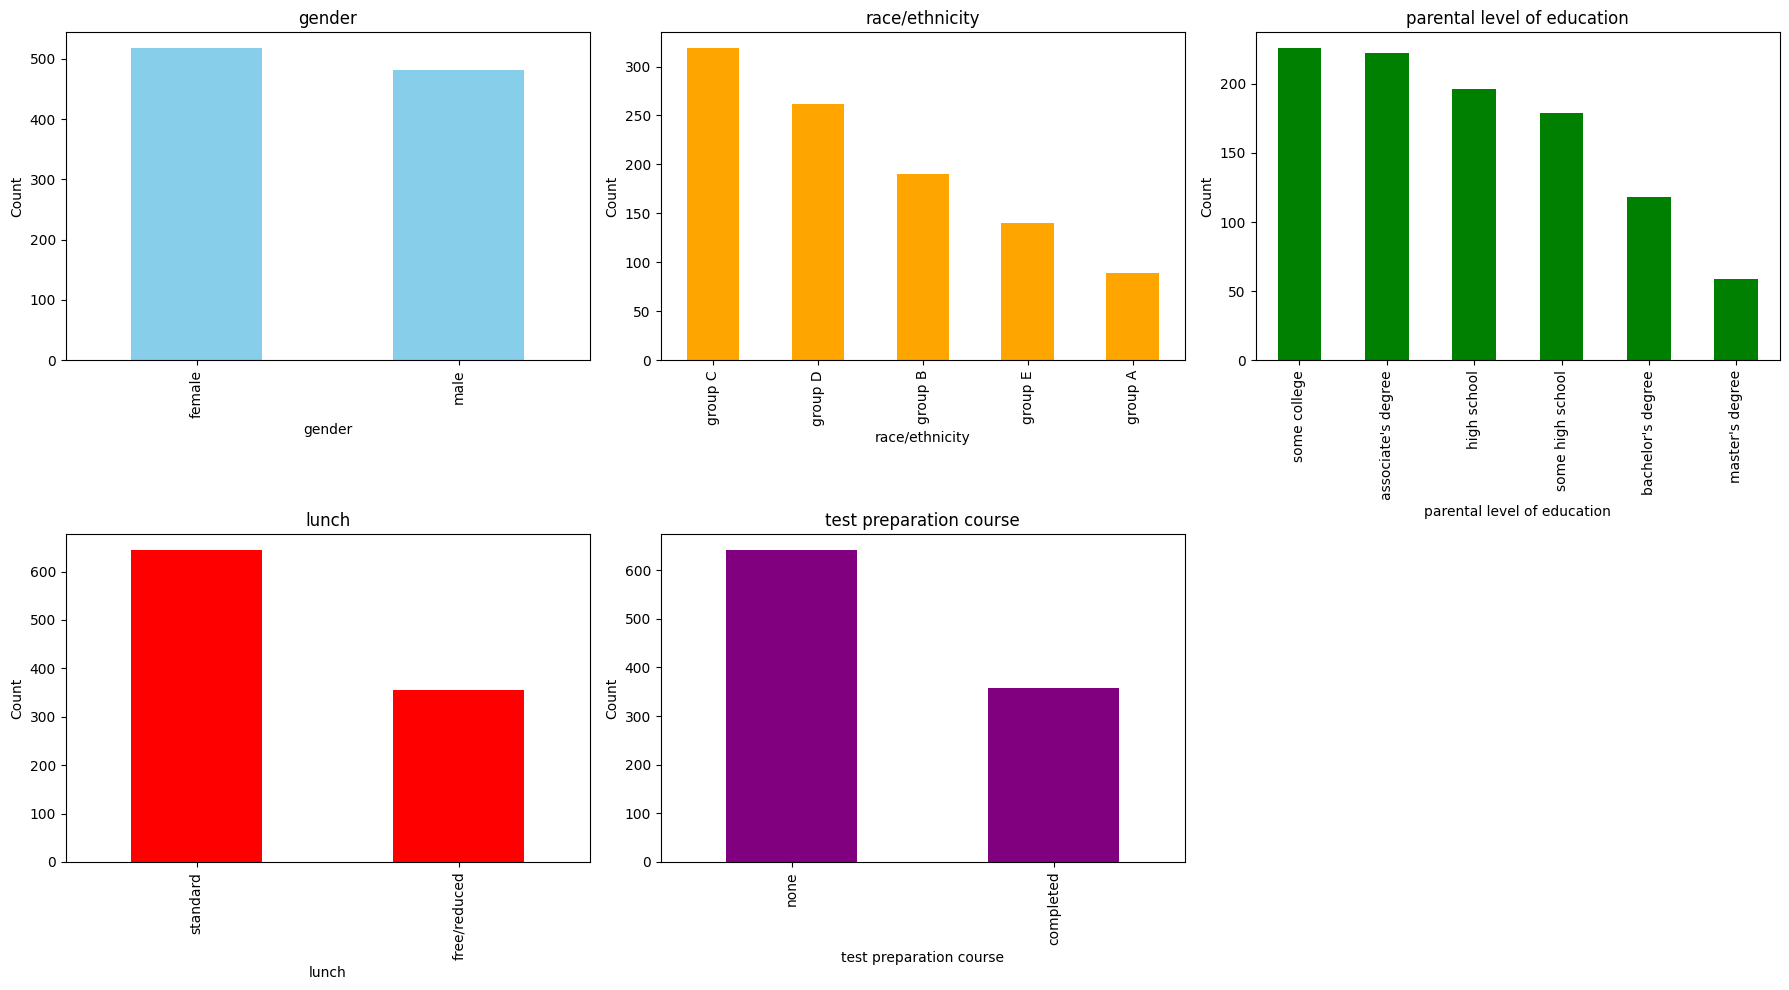

In [7]:
# ============================
# STEP 6
# Categorical Distribution Analysis
# ============================

# List of categorical columns
categorical_columns = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

# Print counts and percentages
for column in categorical_columns:

    print("=" * 60)
    print(f"{column.upper()} VALUE COUNTS")
    print("=" * 60)
    print(df[column].value_counts())

    print("\nPercentage Distribution")
    print(df[column].value_counts(normalize=True) * 100)

    print("\n")

# Colors for charts
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

# Plot each categorical column
for i, column in enumerate(categorical_columns):

    df[column].value_counts().plot(
        kind='bar',
        color=colors[i],
        ax=axes[i]
    )

    axes[i].set_title(column)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Count")

# Remove unused subplot
fig.delaxes(axes[5])

plt.tight_layout()

plt.show()

MEAN SCORES BY GENDER
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31

MEAN SCORES BY RACE/ETHNICITY
                math score  reading score  writing score
race/ethnicity                                          
group A              61.63          64.67          62.67
group B              63.45          67.35          65.60
group C              64.46          69.10          67.83
group D              67.36          70.03          70.15
group E              73.82          73.03          71.41

MEAN SCORES BY PARENTAL EDUCATION
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
high school                       62.

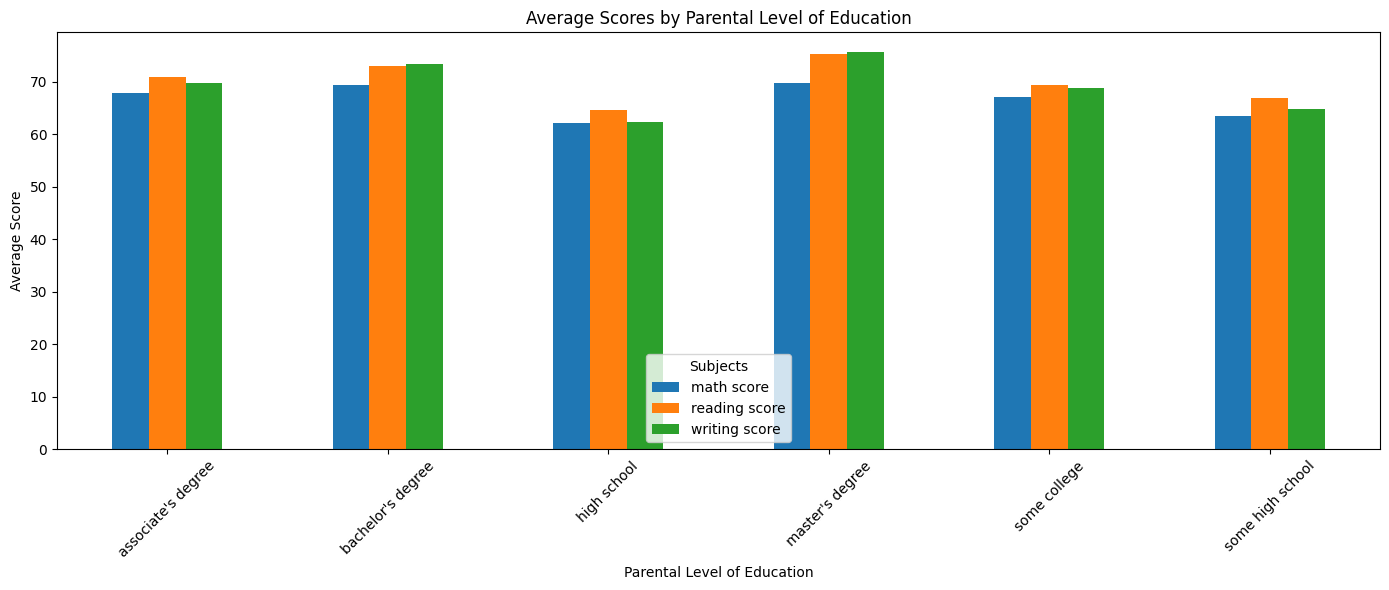

In [8]:
# ============================
# STEP 7
# Group Mean Score Comparisons
# ============================

score_columns = ['math score', 'reading score', 'writing score']

# (a) Mean scores by Gender
print("=" * 60)
print("MEAN SCORES BY GENDER")
print("=" * 60)
print(df.groupby('gender')[score_columns].mean().round(2))

# (b) Mean scores by Race/Ethnicity
print("\n" + "=" * 60)
print("MEAN SCORES BY RACE/ETHNICITY")
print("=" * 60)
print(df.groupby('race/ethnicity')[score_columns].mean().round(2))

# (c) Mean scores by Parental Education
print("\n" + "=" * 60)
print("MEAN SCORES BY PARENTAL EDUCATION")
print("=" * 60)
parent_education = df.groupby('parental level of education')[score_columns].mean().round(2)
print(parent_education)

# (d) Mean scores by Lunch Type
print("\n" + "=" * 60)
print("MEAN SCORES BY LUNCH TYPE")
print("=" * 60)
print(df.groupby('lunch')[score_columns].mean().round(2))

# (e) Mean scores by Test Preparation Course
print("\n" + "=" * 60)
print("MEAN SCORES BY TEST PREPARATION COURSE")
print("=" * 60)
print(df.groupby('test preparation course')[score_columns].mean().round(2))

# ============================
# Grouped Bar Chart
# ============================

parent_education.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title("Average Scores by Parental Level of Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.legend(title="Subjects")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

CORRELATION MATRIX
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


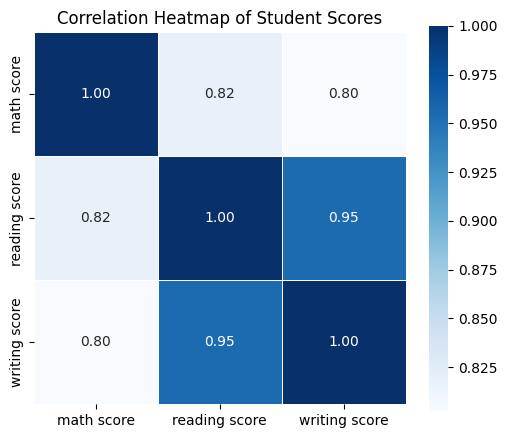


PEARSON CORRELATION
Math vs Reading : 0.82
Reading vs Writing : 0.95


In [9]:
# ============================
# STEP 8
# Correlation Analysis & Heatmap
# ============================

score_cols = ['math score', 'reading score', 'writing score']

# Correlation Matrix
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

correlation_matrix = df[score_cols].corr()

print(correlation_matrix)

# Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Scores")

plt.show()

# Pearson Correlation
math_reading = df['math score'].corr(df['reading score'])
reading_writing = df['reading score'].corr(df['writing score'])

print("\n" + "=" * 60)
print("PEARSON CORRELATION")
print("=" * 60)

print(f"Math vs Reading : {math_reading:.2f}")
print(f"Reading vs Writing : {reading_writing:.2f}")

MEAN SCORES
               Completed   None
math score         69.70  64.08
reading score      73.89  66.53
writing score      74.42  64.50

STANDARD DEVIATION
               Completed   None
math score         14.44  15.19
reading score      13.64  14.46
writing score      13.38  15.00


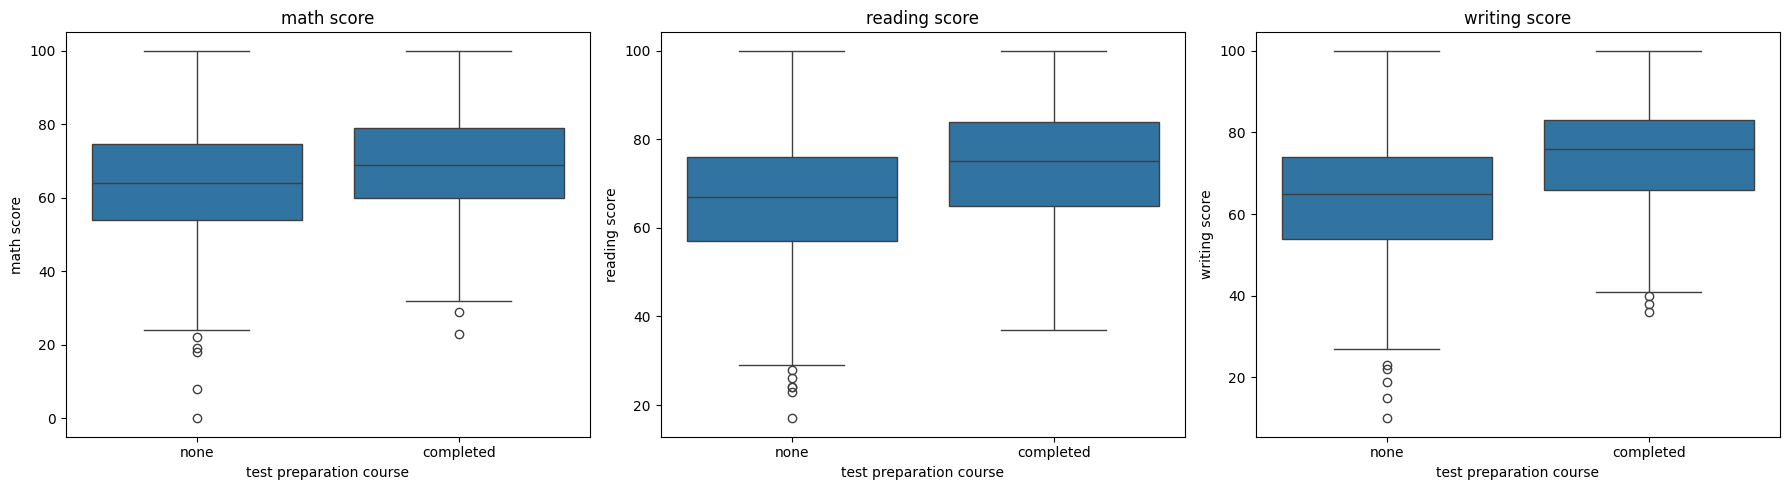


IMPROVEMENT (%)
math score        8.77
reading score    11.06
writing score    15.38
dtype: float64


In [10]:
# ============================
# STEP 9
# Test Preparation Impact Analysis
# ============================

score_cols = ['math score', 'reading score', 'writing score']

# Split into two groups
completed = df[df['test preparation course'] == 'completed']
none = df[df['test preparation course'] == 'none']

# Mean Scores
print("=" * 60)
print("MEAN SCORES")
print("=" * 60)

mean_scores = pd.DataFrame({
    'Completed': completed[score_cols].mean(),
    'None': none[score_cols].mean()
}).round(2)

print(mean_scores)

# Standard Deviation
print("\n" + "=" * 60)
print("STANDARD DEVIATION")
print("=" * 60)

std_scores = pd.DataFrame({
    'Completed': completed[score_cols].std(),
    'None': none[score_cols].std()
}).round(2)

print(std_scores)

# ============================
# Box Plots
# ============================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

subjects = ['math score', 'reading score', 'writing score']

for i, subject in enumerate(subjects):

    sns.boxplot(
        data=df,
        x='test preparation course',
        y=subject,
        ax=axes[i]
    )

    axes[i].set_title(subject)

plt.tight_layout()
plt.show()

# ============================
# Improvement Percentage
# ============================

improvement = ((mean_scores['Completed'] - mean_scores['None'])
               / mean_scores['None']) * 100

print("\n" + "=" * 60)
print("IMPROVEMENT (%)")
print("=" * 60)

print(improvement.round(2))

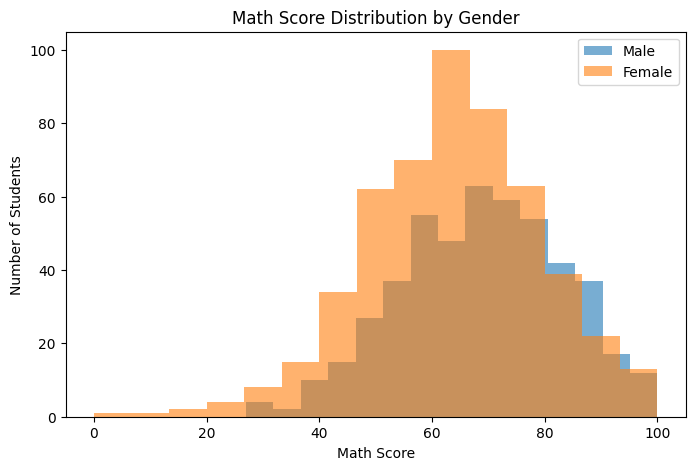

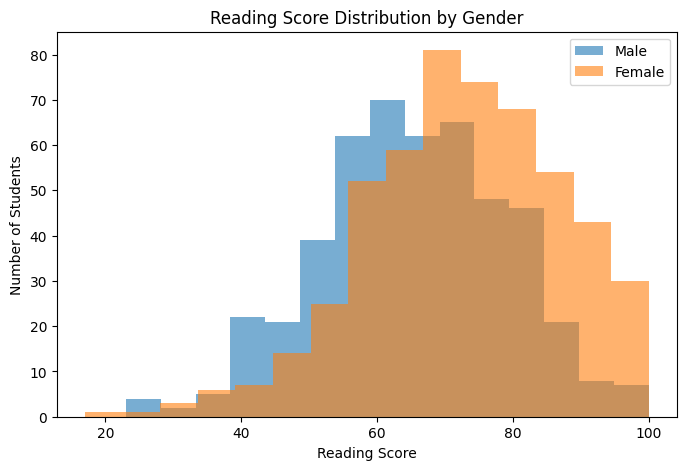

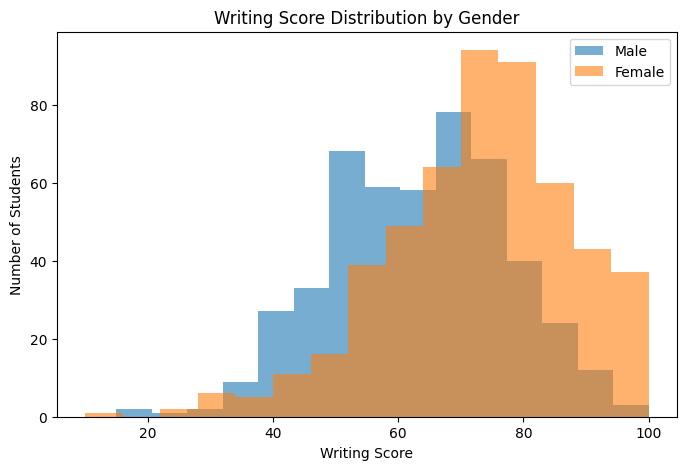

PERCENTAGE OF STUDENTS SCORING ABOVE 70
        math score  reading score  writing score
Male         45.85          38.38          32.16
Female       32.82          58.30          58.11


In [11]:
# ============================
# STEP 10
# Gender Score Deep-Dive
# ============================

subjects = ['math score', 'reading score', 'writing score']

# ----------------------------
# Overlapping Histograms
# ----------------------------

for subject in subjects:

    plt.figure(figsize=(8,5))

    plt.hist(
        df[df['gender']=='male'][subject],
        bins=15,
        alpha=0.6,
        label='Male'
    )

    plt.hist(
        df[df['gender']=='female'][subject],
        bins=15,
        alpha=0.6,
        label='Female'
    )

    plt.title(f'{subject.title()} Distribution by Gender')
    plt.xlabel(subject.title())
    plt.ylabel('Number of Students')

    plt.legend()

    plt.show()

# ----------------------------
# Percentage Above 70
# ----------------------------

summary = pd.DataFrame(index=['Male','Female'])

for subject in subjects:

    male_pct = (
        (df[df['gender']=='male'][subject] > 70).mean()
    ) * 100

    female_pct = (
        (df[df['gender']=='female'][subject] > 70).mean()
    ) * 100

    summary[subject] = [round(male_pct,2), round(female_pct,2)]

print("="*60)
print("PERCENTAGE OF STUDENTS SCORING ABOVE 70")
print("="*60)

print(summary)

In [12]:
# ============================
# STEP 11
# Feature Engineering
# ============================

# (a) Total Score
df['total_score'] = (
    df['math score']
    + df['reading score']
    + df['writing score']
)

# (b) Average Score
df['average_score'] = df['total_score'] / 3

# (c) Performance Grade
def assign_grade(avg):

    if avg >= 80:
        return 'A'

    elif avg >= 70:
        return 'B'

    elif avg >= 60:
        return 'C'

    elif avg >= 50:
        return 'D'

    else:
        return 'F'

df['performance_grade'] = df['average_score'].apply(assign_grade)

# (d) High Achiever
df['high_achiever'] = df['average_score'] >= 80

# (e) Lowest Subject
score_cols = ['math score', 'reading score', 'writing score']

df['lowest_subject'] = df[score_cols].idxmin(axis=1)

# ----------------------------
# Display Results
# ----------------------------

print("="*60)
print("FIRST 10 ROWS WITH NEW FEATURES")
print("="*60)

print(df.head(10))

print("\n" + "="*60)
print("PERFORMANCE GRADE COUNTS")
print("="*60)

print(df['performance_grade'].value_counts())

print("\n" + "="*60)
print("LOWEST SUBJECT COUNTS")
print("="*60)

print(df['lowest_subject'].value_counts())

FIRST 10 ROWS WITH NEW FEATURES
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90   

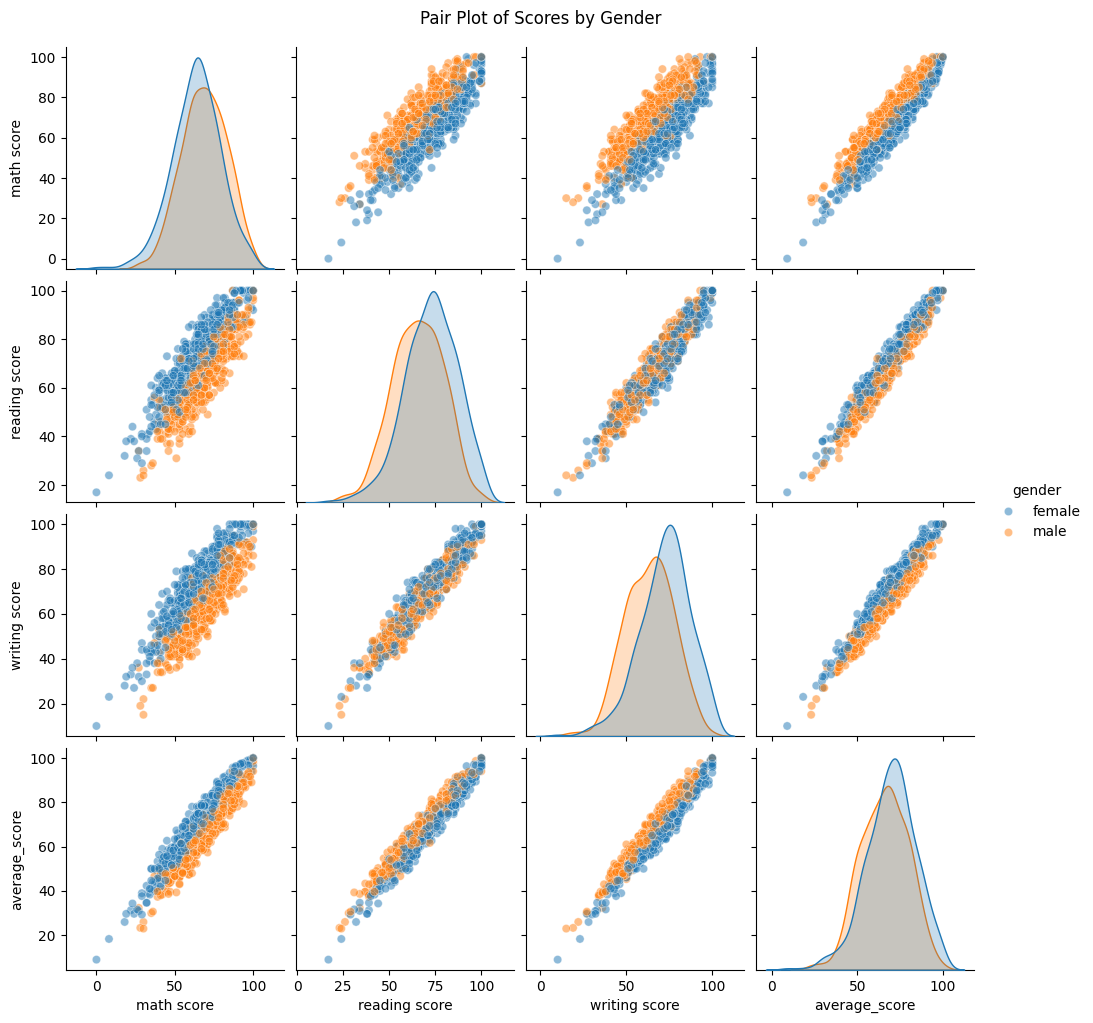

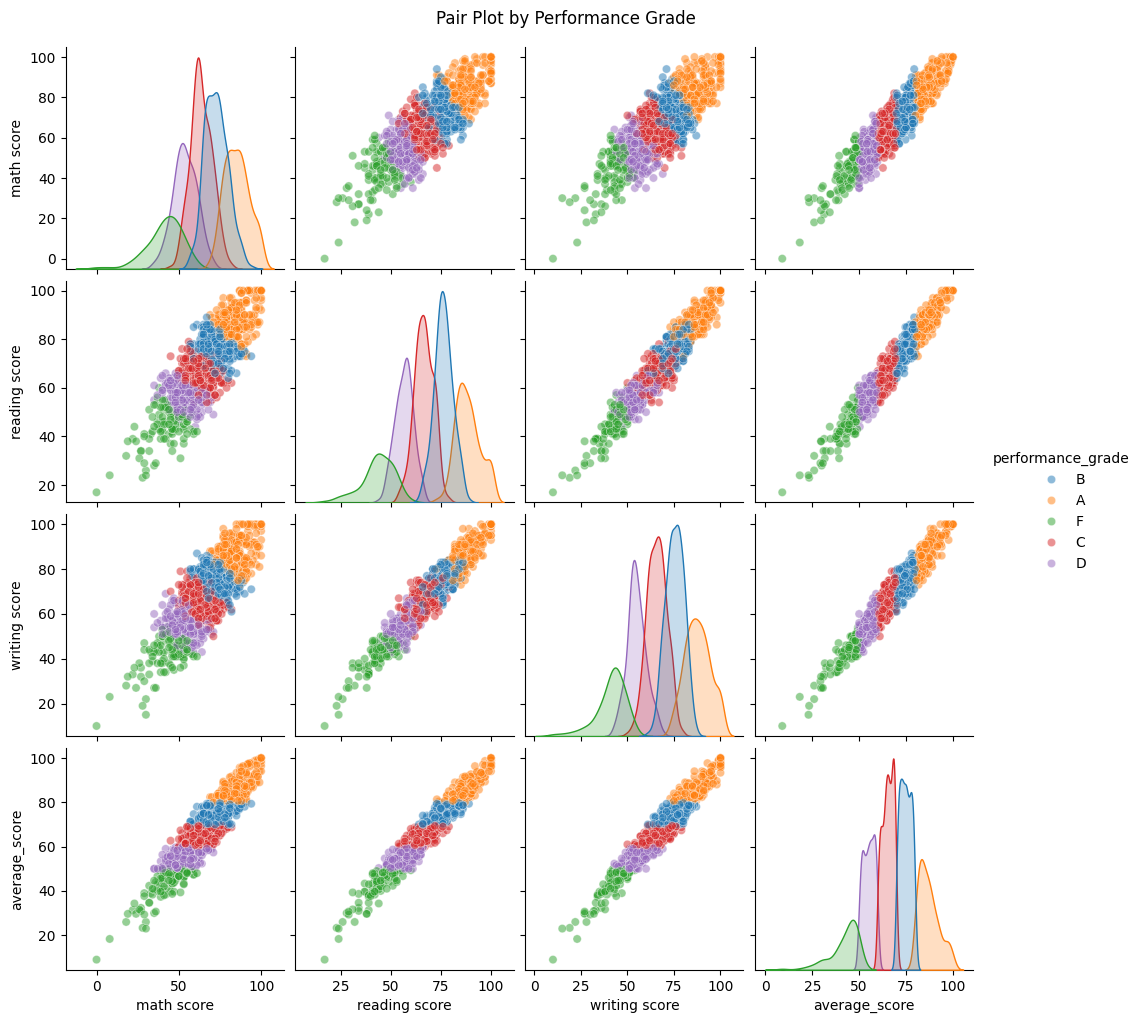

In [13]:
# ============================
# STEP 12
# Pair Plot Multi-Variable Analysis
# ============================

pair_columns = [
    'math score',
    'reading score',
    'writing score',
    'average_score'
]

# ----------------------------
# Pair Plot by Gender
# ----------------------------

pairplot_gender = sns.pairplot(
    df[pair_columns + ['gender']],
    hue='gender',
    plot_kws={'alpha':0.5}
)

pairplot_gender.fig.suptitle(
    "Pair Plot of Scores by Gender",
    y=1.02
)

pairplot_gender.savefig(
    "pairplot_scores.png",
    dpi=150
)

plt.show()

# ----------------------------
# Pair Plot by Performance Grade
# ----------------------------

pairplot_grade = sns.pairplot(
    df[pair_columns + ['performance_grade']],
    hue='performance_grade',
    plot_kws={'alpha':0.5}
)

pairplot_grade.fig.suptitle(
    "Pair Plot by Performance Grade",
    y=1.02
)

pairplot_grade.savefig(
    "pairplot_grades.png",
    dpi=150
)

plt.show()

PIVOT TABLE 1
gender                       female   male
parental level of education               
associate's degree            71.12  67.87
bachelor's degree             74.67  68.78
high school                   64.75  61.58
master's degree               73.65  73.52
some college                  71.00  65.72
some high school              65.56  64.64


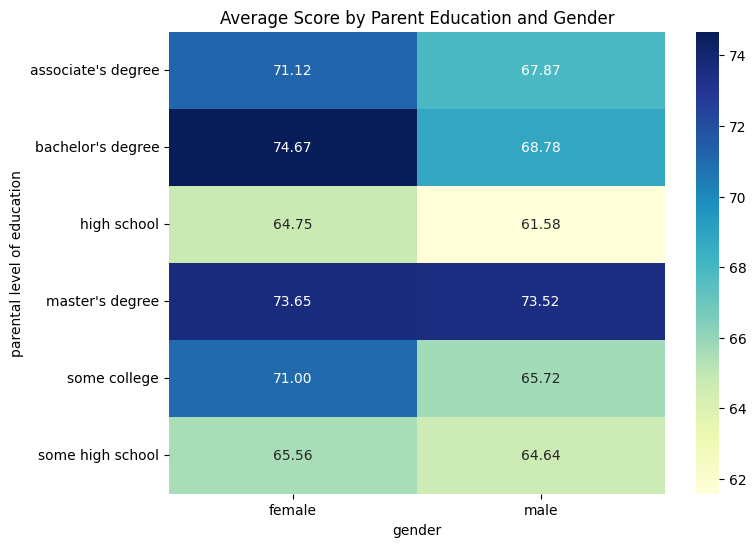


PIVOT TABLE 2
test preparation course  completed   none
race/ethnicity                           
group A                      68.26  58.09
group B                      67.19  61.37
group C                      67.50  62.71
group D                      69.79  66.26
group E                      77.43  71.11


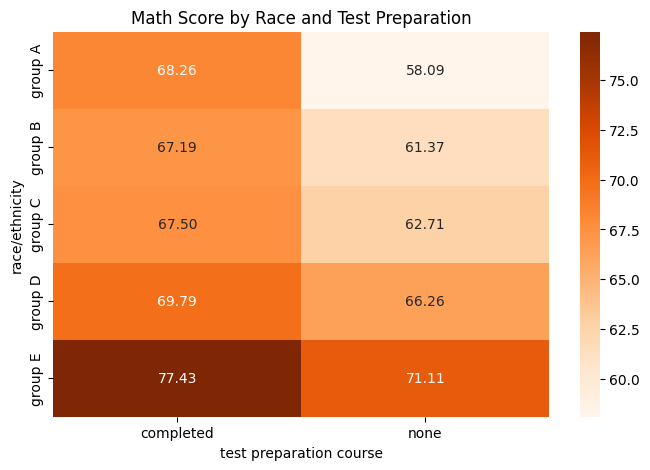

In [14]:
# ============================
# STEP 13
# Pivot Tables & Advanced Grouping
# ============================

# ----------------------------
# Pivot Table 1
# ----------------------------

pivot1 = pd.pivot_table(
    df,
    values='average_score',
    index='parental level of education',
    columns='gender',
    aggfunc='mean'
).round(2)

print("="*60)
print("PIVOT TABLE 1")
print("="*60)

print(pivot1)

# Heatmap 1
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot1,
    annot=True,
    cmap='YlGnBu',
    fmt=".2f"
)

plt.title("Average Score by Parent Education and Gender")

plt.show()

# ----------------------------
# Pivot Table 2
# ----------------------------

pivot2 = pd.pivot_table(
    df,
    values='math score',
    index='race/ethnicity',
    columns='test preparation course',
    aggfunc='mean'
).round(2)

print("\n" + "="*60)
print("PIVOT TABLE 2")
print("="*60)

print(pivot2)

# Heatmap 2
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot2,
    annot=True,
    cmap='Oranges',
    fmt=".2f"
)

plt.title("Math Score by Race and Test Preparation")

plt.show()

SCORE SUMMARY
{'Mean': np.float64(66.089), 'Median': 66.0, 'Std Dev': 15.163080096009468, 'Min': 0, 'Max': 100, 'Pct Above 70': np.float64(39.1)}




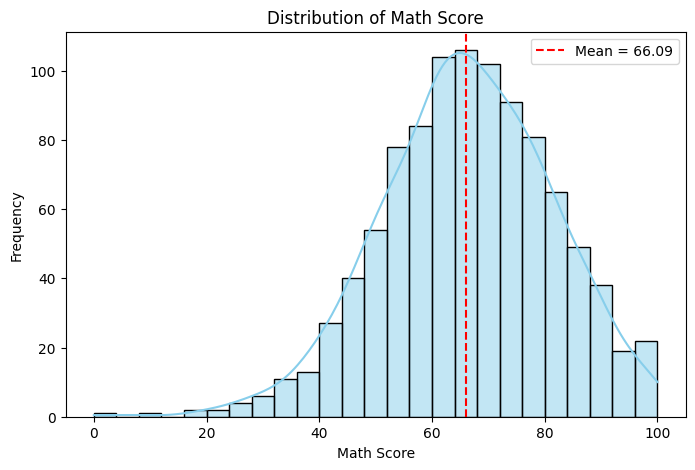

GROUP COMPARISON
         Mean  Pct_Above_70
gender                     
male    68.73         45.85
female  63.63         32.82


In [15]:
# ============================
# STEP 14
# Reusable Python Functions
# ============================

# --------------------------------
# Function 1
# --------------------------------

def score_summary(df, col):
    """
    Returns summary statistics for a score column.
    """

    summary = {
        "Mean": df[col].mean(),
        "Median": df[col].median(),
        "Std Dev": df[col].std(),
        "Min": df[col].min(),
        "Max": df[col].max(),
        "Pct Above 70": (df[col] > 70).mean() * 100
    }

    return summary


# --------------------------------
# Function 2
# --------------------------------

def plot_distribution(df, col, color):

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True,
        color=color
    )

    plt.axvline(
        df[col].mean(),
        color='red',
        linestyle='--',
        label=f"Mean = {df[col].mean():.2f}"
    )

    plt.title(f"Distribution of {col.title()}")
    plt.xlabel(col.title())
    plt.ylabel("Frequency")

    plt.legend()

    plt.show()


# --------------------------------
# Function 3
# --------------------------------

def compare_groups(df, group_col, score_col):

    result = df.groupby(group_col).agg(
        Mean=(score_col, 'mean'),
        Pct_Above_70=(score_col, lambda x: (x > 70).mean()*100)
    )

    result = result.round(2)

    result = result.sort_values(
        by='Mean',
        ascending=False
    )

    return result


# ============================
# Calling Functions
# ============================

print("="*60)
print("SCORE SUMMARY")
print("="*60)

print(score_summary(df, 'math score'))

print("\n")

plot_distribution(df, 'math score', 'skyblue')

print("="*60)
print("GROUP COMPARISON")
print("="*60)

print(compare_groups(
    df,
    'gender',
    'math score'
))

In [16]:
# ============================
# STEP 15
# NumPy Statistical Computations
# ============================

import numpy as np

# Extract NumPy arrays
math_scores = df['math score'].values
reading_scores = df['reading score'].values
writing_scores = df['writing score'].values

subjects = {
    'Math': math_scores,
    'Reading': reading_scores,
    'Writing': writing_scores
}

# ----------------------------
# (a) Statistics
# ----------------------------

print("="*60)
print("NUMPY STATISTICS")
print("="*60)

stats = []

for subject, scores in subjects.items():

    stats.append([
        subject,
        np.mean(scores),
        np.median(scores),
        np.std(scores),
        np.var(scores),
        np.min(scores),
        np.max(scores)
    ])

stats_df = pd.DataFrame(
    stats,
    columns=[
        'Subject',
        'Mean',
        'Median',
        'Std Dev',
        'Variance',
        'Minimum',
        'Maximum'
    ]
)

print(stats_df.round(2))

# ----------------------------
# (b) Z-Scores
# ----------------------------

print("\n" + "="*60)
print("Z-SCORE ANALYSIS")
print("="*60)

for subject, scores in subjects.items():

    z_scores = (scores - np.mean(scores)) / np.std(scores)

    high = np.sum(z_scores > 2)

    low = np.sum(z_scores < -2)

    print(f"{subject}:")
    print(f"Z > +2 : {high}")
    print(f"Z < -2 : {low}")
    print()

# ----------------------------
# (c) Percentiles
# ----------------------------

percentiles = [10,25,50,75,90]

percentile_data = []

for subject, scores in subjects.items():

    values = np.percentile(scores, percentiles)

    percentile_data.append(values)

percentile_df = pd.DataFrame(
    percentile_data,
    index=['Math','Reading','Writing'],
    columns=['10th','25th','50th','75th','90th']
)

print("="*60)
print("PERCENTILES")
print("="*60)

print(percentile_df)

# ----------------------------
# (d) Top 10 Math Scorers
# ----------------------------

top10 = np.argsort(math_scores)[-10:][::-1]

print("\n" + "="*60)
print("TOP 10 MATH SCORER INDEXES")
print("="*60)

print(top10)

# ----------------------------
# (e) Pass Rate
# ----------------------------

print("\n" + "="*60)
print("PASS RATE (>70)")
print("="*60)

for subject, scores in subjects.items():

    pass_array = (scores > 70).astype(int)

    pass_rate = np.mean(pass_array)*100

    print(f"{subject}: {pass_rate:.2f}%")

NUMPY STATISTICS
   Subject   Mean  Median  Std Dev  Variance  Minimum  Maximum
0     Math  66.09    66.0    15.16    229.69        0      100
1  Reading  69.17    70.0    14.59    212.95       17      100
2  Writing  68.05    69.0    15.19    230.68       10      100

Z-SCORE ANALYSIS
Math:
Z > +2 : 19
Z < -2 : 27

Reading:
Z > +2 : 20
Z < -2 : 26

Writing:
Z > +2 : 18
Z < -2 : 24

PERCENTILES
         10th   25th  50th  75th  90th
Math     47.0  57.00  66.0  77.0  86.0
Reading  51.0  59.00  70.0  79.0  87.1
Writing  48.0  57.75  69.0  79.0  87.0

TOP 10 MATH SCORER INDEXES
[916 458 962 625 623 451 149 306 114 263]

PASS RATE (>70)
Math: 39.10%
Reading: 48.70%
Writing: 45.60%


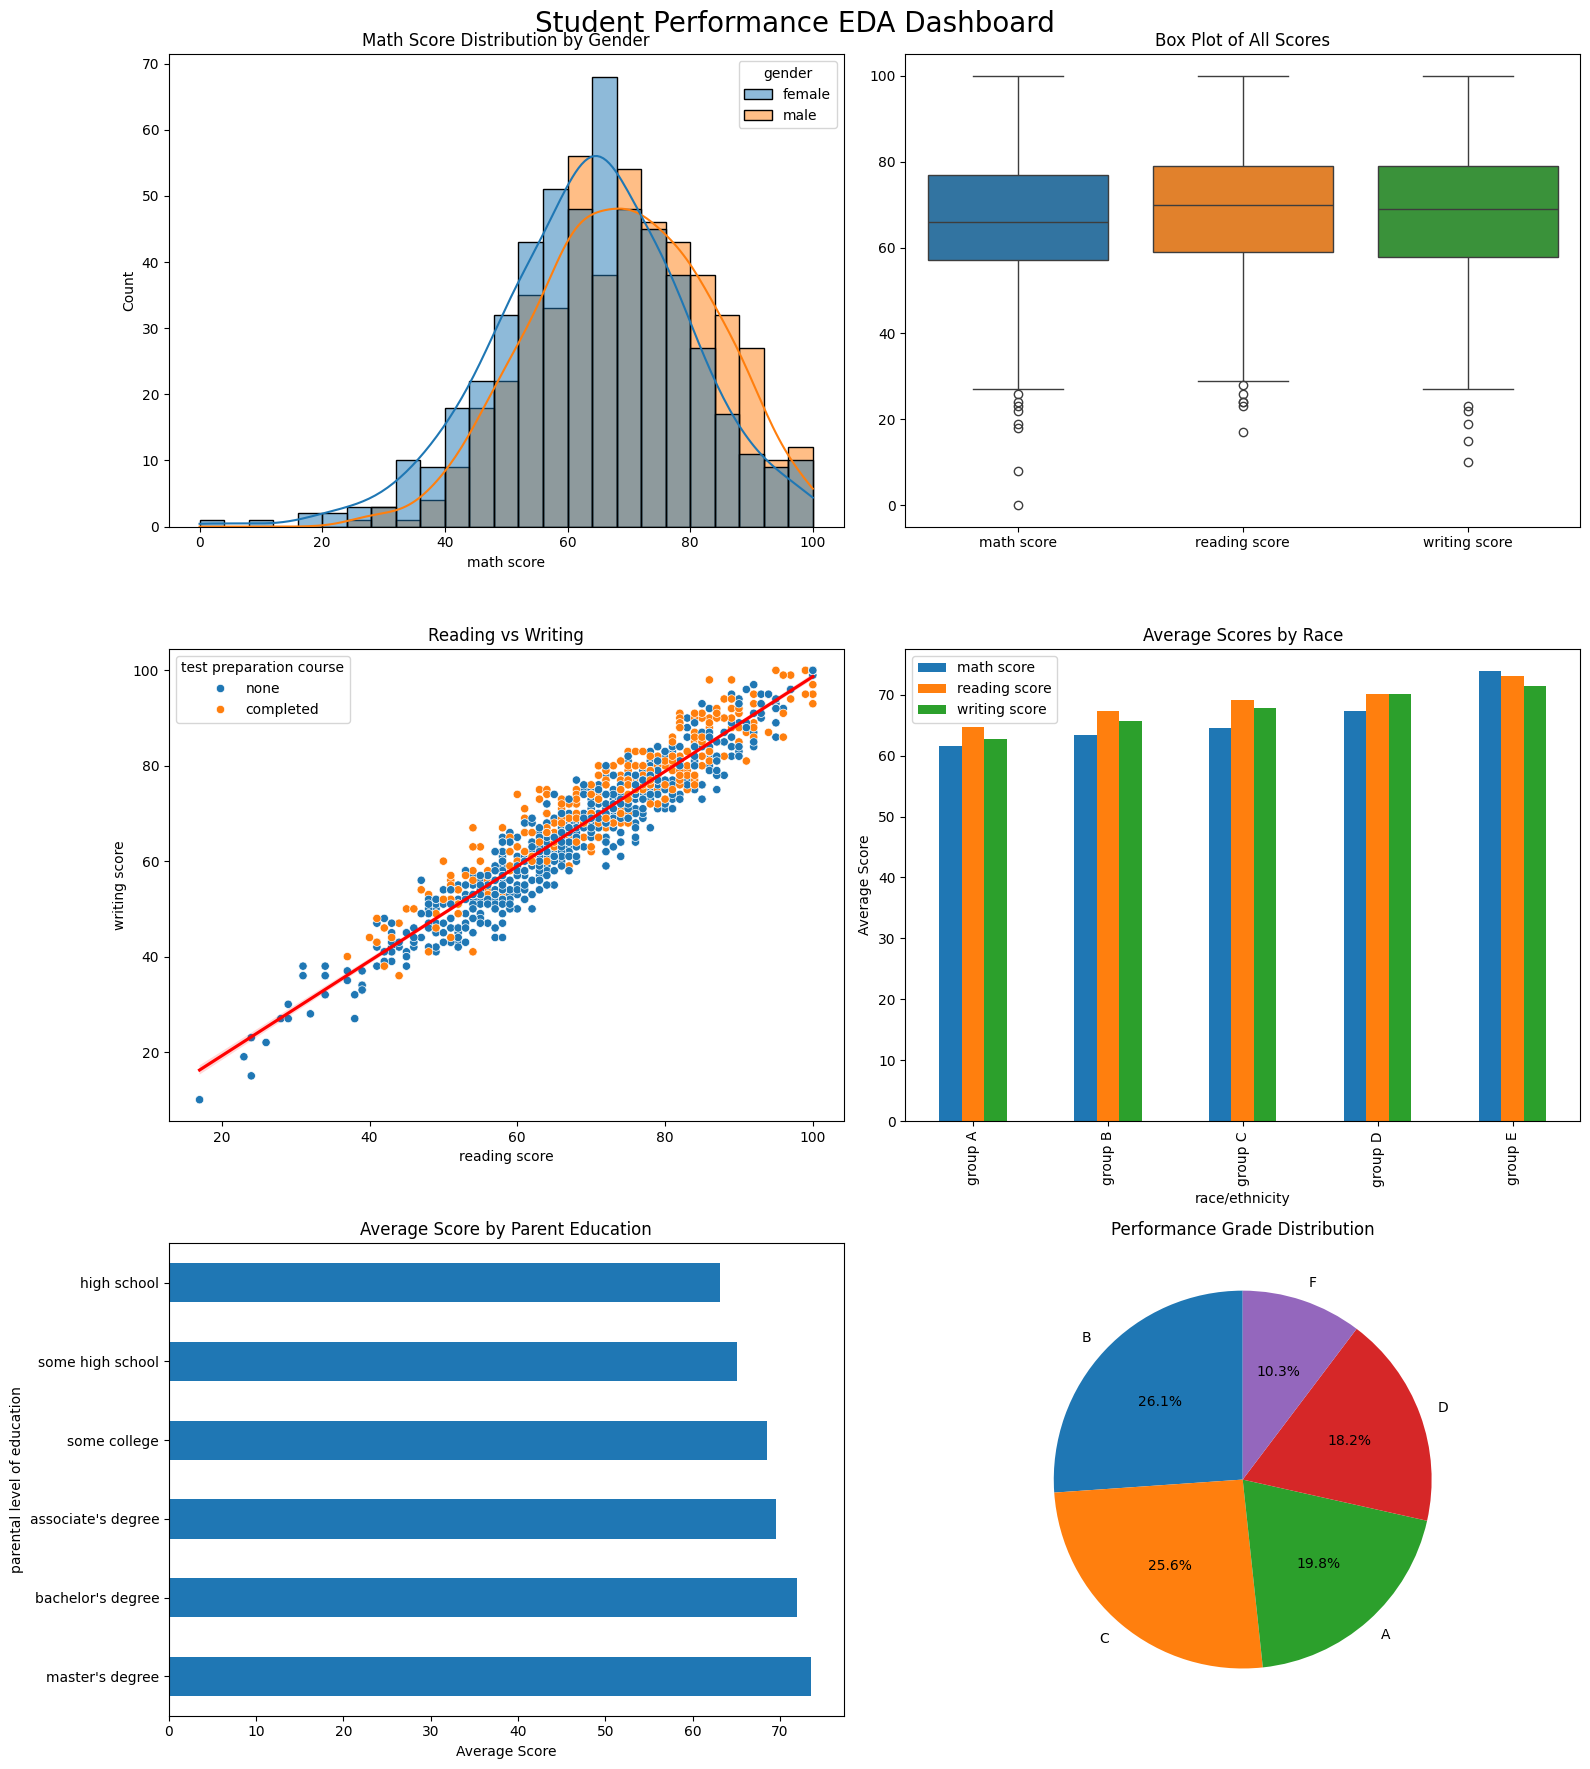

In [17]:
# ============================
# STEP 16
# Professional EDA Dashboard
# ============================

fig, axes = plt.subplots(3, 2, figsize=(16,18))

# -----------------------------
# Chart 1
# Histogram + KDE by Gender
# -----------------------------

sns.histplot(
    data=df,
    x='math score',
    hue='gender',
    kde=True,
    ax=axes[0,0]
)

axes[0,0].set_title("Math Score Distribution by Gender")

# -----------------------------
# Chart 2
# Box Plot
# -----------------------------

sns.boxplot(
    data=df[['math score','reading score','writing score']],
    ax=axes[0,1]
)

axes[0,1].set_title("Box Plot of All Scores")

# -----------------------------
# Chart 3
# Scatter + Regression
# -----------------------------

sns.scatterplot(
    data=df,
    x='reading score',
    y='writing score',
    hue='test preparation course',
    ax=axes[1,0]
)

sns.regplot(
    data=df,
    x='reading score',
    y='writing score',
    scatter=False,
    color='red',
    ax=axes[1,0]
)

axes[1,0].set_title("Reading vs Writing")

# -----------------------------
# Chart 4
# Race Average Scores
# -----------------------------

race_mean = df.groupby('race/ethnicity')[
    ['math score','reading score','writing score']
].mean()

race_mean.plot(
    kind='bar',
    ax=axes[1,1]
)

axes[1,1].set_title("Average Scores by Race")
axes[1,1].set_ylabel("Average Score")

# -----------------------------
# Chart 5
# Horizontal Bar
# -----------------------------

parent_mean = df.groupby(
    'parental level of education'
)['average_score'].mean().sort_values(ascending=False)

parent_mean.plot(
    kind='barh',
    ax=axes[2,0]
)

axes[2,0].set_title("Average Score by Parent Education")
axes[2,0].set_xlabel("Average Score")

# -----------------------------
# Chart 6
# Pie Chart
# -----------------------------

grade_counts = df['performance_grade'].value_counts()

axes[2,1].pie(
    grade_counts,
    labels=grade_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

axes[2,1].set_title("Performance Grade Distribution")

# -----------------------------
# Dashboard Title
# -----------------------------

fig.suptitle(
    "Student Performance EDA Dashboard",
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    "eda_dashboard.png",
    dpi=150
)

plt.show()

In [ ]:
# 1. Executive Summary

# This project analyzes a student performance dataset containing demographic information and scores in mathematics, reading, and writing. The objective was to explore the data, understand the relationships between different variables, and identify factors that influence academic performance. Exploratory Data Analysis (EDA), statistical analysis, feature engineering, and data visualization techniques were used throughout the project. The analysis showed that factors such as parental education level and completion of the test preparation course are associated with better academic performance. The project also demonstrated the use of Python libraries such as NumPy, Pandas, Matplotlib, and Seaborn for performing data analysis and visualization.

In [ ]:
# 3. Key Statistical Findings

# Descriptive statistics showed that reading and writing scores generally had higher average values than mathematics scores. Correlation analysis revealed a strong positive relationship among all three subjects, with reading and writing showing the highest correlation. Students who completed the test preparation course achieved higher average scores across all subjects compared to students who did not complete the course. The analysis also indicated that students whose parents had higher levels of education generally achieved better academic results. Feature engineering created additional variables such as total score, average score, performance grade, and high achiever status, which provided a more comprehensive understanding of student performance.

In [ ]:
# 3. Key Statistical Findings

# Descriptive statistics showed that reading and writing scores generally had higher average values than mathematics scores. Correlation analysis revealed a strong positive relationship among all three subjects, with reading and writing showing the highest correlation. Students who completed the test preparation course achieved higher average scores across all subjects compared to students who did not complete the course. The analysis also indicated that students whose parents had higher levels of education generally achieved better academic results. Feature engineering created additional variables such as total score, average score, performance grade, and high achiever status, which provided a more comprehensive understanding of student performance.

In [ ]:
# 4. Visualization Insights
#
# The visualizations provided valuable insights into the dataset. Histograms showed the distribution of scores across different subjects, while box plots highlighted differences in score variability and potential outliers. Scatter plots demonstrated a strong positive relationship between reading and writing scores, supported by the regression line. Heatmaps made it easy to identify correlations and compare average scores across different groups. Pair plots revealed that students with different performance grades formed more distinct clusters than students grouped by gender. The final dashboard combined multiple visualizations into a single figure, making it easier to understand the overall characteristics of the dataset.

In [ ]:
# 5. Feature Engineering Rationale

# Feature engineering was performed to create additional variables that provide more meaningful information than the original dataset alone. Total score and average score summarize overall academic performance, while the performance grade categorizes students into different achievement levels. The high achiever feature identifies students with strong overall performance, and the lowest subject feature indicates the area where each student needs improvement. These new features make the dataset more useful for analysis and future machine learning models.

In [ ]:
# 6. Actionable Recommendations for Educators

# Based on the analysis, schools should encourage more students to participate in test preparation programs because students who completed the course consistently achieved higher scores. Additional academic support should be provided to students who perform poorly in their weakest subjects, allowing them to improve their overall performance. Schools should also promote reading and writing activities because these subjects show a strong positive relationship. Parents should be encouraged to remain actively involved in their children's education, as higher parental education levels were associated with improved student performance. Regular progress monitoring and personalized learning plans can further help students achieve better academic outcomes.

In [ ]:
# 7. Reflection & Lessons Learned

# This project provided practical experience in performing exploratory data analysis using Python. I learned how to load, inspect, clean, visualize, and analyze a dataset using Pandas, NumPy, Matplotlib, and Seaborn. I also learned the importance of feature engineering, statistical analysis, pivot tables, reusable Python functions, and data visualization in understanding datasets. The project demonstrated that meaningful insights can be obtained through careful analysis before applying machine learning algorithms. Overall, this assignment strengthened my programming, analytical, and data visualization skills.